In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import joblib
import os

In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack_type','difficulty_level'
]

df_train = pd.read_csv('/Users/prashantmeena/Documents/projects/Intrusion Detection System /data/raw/KDDTrain+.txt', header=None, names=columns)
df_test  = pd.read_csv('/Users/prashantmeena/Documents/projects/Intrusion Detection System /data/raw/KDDTest+.txt',  header=None, names=columns)

# drop difficulty_level — not a feature, not a label
df_train.drop('difficulty_level', axis=1, inplace=True)
df_test.drop('difficulty_level',  axis=1, inplace=True)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (125973, 42)
Test shape:  (22544, 42)


In [3]:
attack_map = {
    'normal': 'Normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS',
    'udpstorm': 'DoS', 'processtable': 'DoS', 'worm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
}

label_map = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}

df_train['label'] = df_train['attack_type'].map(attack_map).map(label_map)
df_test['label']  = df_test['attack_type'].map(attack_map).map(label_map)

# drop rows where attack type was unknown (maps to NaN)
df_train.dropna(subset=['label'], inplace=True)
df_test.dropna(subset=['label'],  inplace=True)

df_train['label'] = df_train['label'].astype(int)
df_test['label']  = df_test['label'].astype(int)

print(df_train['label'].value_counts())

label
0    67343
1    45927
2    11656
3      995
4       52
Name: count, dtype: int64


In [4]:
cat_cols = ['protocol_type', 'service', 'flag']
drop_cols = ['attack_type', 'label']

X_train_raw = df_train.drop(drop_cols, axis=1)
X_test_raw  = df_test.drop(drop_cols,  axis=1)

y_train = df_train['label'].values
y_test  = df_test['label'].values

In [5]:
# fit ONLY on train — never fit on test data
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train_raw[cat_cols])

# transform both train and test using the same fitted encoder
train_cat = ohe.transform(X_train_raw[cat_cols])
test_cat  = ohe.transform(X_test_raw[cat_cols])

# numeric columns (everything except the 3 categorical ones)
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

train_num = X_train_raw[num_cols].values
test_num  = X_test_raw[num_cols].values

# combine: numeric + one-hot columns
X_train_combined = np.hstack([train_num, train_cat])
X_test_combined  = np.hstack([test_num,  test_cat])

print(f"Feature count after OHE: {X_train_combined.shape[1]}")

Feature count after OHE: 122


In [6]:
# fit ONLY on train
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train_combined)

X_train_scaled = scaler.transform(X_train_combined)
X_test_scaled  = scaler.transform(X_test_combined)

print(f"Min value in train: {X_train_scaled.min():.3f}")
print(f"Max value in train: {X_train_scaled.max():.3f}")
# both should be 0.0 and 1.0

Min value in train: 0.000
Max value in train: 1.000


In [7]:
# autoencoder trains ONLY on normal traffic (label == 0)
normal_mask = (y_train == 0)
X_train_normal = X_train_scaled[normal_mask]

print(f"Full train set:   {X_train_scaled.shape}")
print(f"Normal-only set:  {X_train_normal.shape}")

Full train set:   (125973, 122)
Normal-only set:  (67343, 122)


In [8]:
os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/X_train.npy', X_train_scaled)
np.save('../data/processed/X_test.npy',  X_test_scaled)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)
np.save('../data/processed/X_train_normal.npy', X_train_normal)

# save the fitted encoder and scaler together
joblib.dump({'ohe': ohe, 'scaler': scaler, 'num_cols': num_cols},
            '../data/processed/encoder_artifacts.pkl')

print("All files saved to data/processed/")

All files saved to data/processed/


In [9]:
# sanity check — reload and confirm shapes
X_tr = np.load('../data/processed/X_train.npy')
X_te = np.load('../data/processed/X_test.npy')
y_tr = np.load('../data/processed/y_train.npy')
y_te = np.load('../data/processed/y_test.npy')
X_normal = np.load('../data/processed/X_train_normal.npy')

print(f"X_train:       {X_tr.shape}")
print(f"X_test:        {X_te.shape}")
print(f"y_train:       {y_tr.shape}")
print(f"y_test:        {y_te.shape}")
print(f"X_train_normal:{X_normal.shape}")

X_train:       (125973, 122)
X_test:        (22251, 122)
y_train:       (125973,)
y_test:        (22251,)
X_train_normal:(67343, 122)


In [10]:
# NSL-KDD's documented 3-way feature taxonomy, by original column name
basic_num = ['duration','src_bytes','dst_bytes','land','wrong_fragment','urgent']
content_num = ['hot','num_failed_logins','logged_in','num_compromised','root_shell',
               'su_attempted','num_root','num_file_creations','num_shells',
               'num_access_files','num_outbound_cmds','is_host_login','is_guest_login']
traffic_num = ['count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
               'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
               'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
               'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
               'dst_host_srv_diff_host_rate','dst_host_serror_rate',
               'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate']

# assign a group to each numeric column, in num_cols order (this IS the column order in X_train_combined)
num_col_groups = []
for col in num_cols:
    if col in basic_num:
        num_col_groups.append('basic')
    elif col in content_num:
        num_col_groups.append('content')
    elif col in traffic_num:
        num_col_groups.append('traffic')
    else:
        raise ValueError(f"Unassigned column: {col}")

# protocol_type/service/flag are categorical "basic" features — every one-hot column
# derived from them inherits that group
n_ohe_cols = train_cat.shape[1]
ohe_groups = ['basic'] * n_ohe_cols

# concatenated in the SAME order as np.hstack([train_num, train_cat])
feature_groups = np.array(num_col_groups + ohe_groups)

print(f"Total columns: {len(feature_groups)}")
for g in ['basic', 'content', 'traffic']:
    print(f"  {g:8s}: {(feature_groups == g).sum()} columns")

content_idx = np.where(feature_groups == 'content')[0]
basic_idx   = np.where(feature_groups == 'basic')[0]
traffic_idx = np.where(feature_groups == 'traffic')[0]

Total columns: 122
  basic   : 90 columns
  content : 13 columns
  traffic : 19 columns


In [11]:
np.save('../data/processed/content_idx.npy', content_idx)
np.save('../data/processed/traffic_idx.npy', traffic_idx)
np.save('../data/processed/basic_idx.npy', basic_idx)
print("Saved feature group indices to data/raw/")

Saved feature group indices to data/raw/


Normal-only training rows for the Gaussian fit: (67343, 5)
Train score mean/median: 3.379488455223822 0.01783314020777706
Test score mean/median: 15.540627413554503 0.01783314020777706


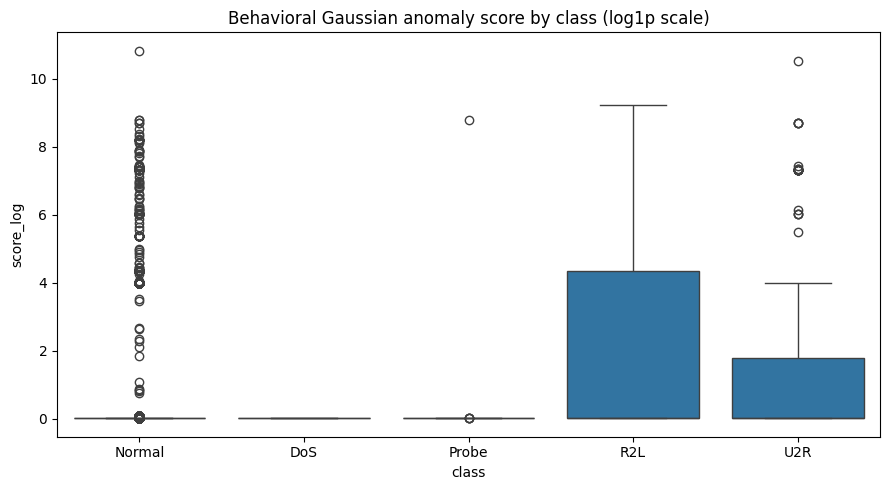

Normal   n= 77054 median=0.018 mean=4.630 p90=0.018
DoS      n= 53094 median=0.018 mean=0.018 p90=0.018
Probe    n= 14077 median=0.018 mean=0.487 p90=0.018
R2L      n=  3880 median=0.018 mean=82.252 p90=407.347
U2R      n=   119 median=0.018 mean=738.195 p90=1495.538
 threshold   Normal      DoS    Probe      R2L      U2R
         1    1.89%    0.00%    0.01%   34.92%   25.21%
         5    1.89%    0.00%    0.01%   34.92%   25.21%
        10    1.88%    0.00%    0.01%   34.92%   25.21%
        50    1.88%    0.00%    0.01%   34.92%   24.37%
       100    0.24%    0.00%    0.01%   13.69%   21.85%
       400    0.19%    0.00%    0.01%   13.61%   21.01%
      1000    0.10%    0.00%    0.01%    0.26%   17.65%
Saved behavioral Gaussian score arrays to ../data/preprocessed/


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

behavioral_cols = ["num_failed_logins", "num_root", "num_shells",
                    "is_guest_login", "num_access_files"]

X_train_behav = df_train[behavioral_cols].values.astype(float)
X_test_behav  = df_test [behavioral_cols].values.astype(float)
X_train_behav_normal = X_train_behav[y_train == 0]
print("Normal-only training rows for the Gaussian fit:", X_train_behav_normal.shape)

# Diagonal-covariance Gaussian fit on Normal-only rows.
# Diagonal, not full covariance: is_guest_login is near-binary and
# num_shells/num_root are near-zero for almost all non-U2R traffic —
# full covariance risks near-singularity here.
mu  = X_train_behav_normal.mean(axis=0)
var = np.maximum(X_train_behav_normal.var(axis=0), 1e-8)

def gaussian_anomaly_score(X, mu, var):
    z = (X - mu) / np.sqrt(var)
    return np.sum(z ** 2, axis=1)

score_train = gaussian_anomaly_score(X_train_behav, mu, var)
score_test  = gaussian_anomaly_score(X_test_behav, mu, var)
print("Train score mean/median:", score_train.mean(), np.median(score_train))
print("Test score mean/median:", score_test.mean(), np.median(score_test))

# --- Gate check 1: boxplot by class, log scale (mirrors notebook 03 Cell 8) ---
label_names = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
plot_df = pd.DataFrame({
    "score": np.concatenate([score_train, score_test]),
    "label": np.concatenate([y_train, y_test]),
})
plot_df["class"] = plot_df["label"].map(label_names)
plot_df["score_log"] = np.log1p(plot_df["score"])

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="class", y="score_log",
            order=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("Behavioral Gaussian anomaly score by class (log1p scale)")
plt.tight_layout()
plt.savefig("../reports/behavioral_gaussian_score_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

for cls_id, cls_name in label_names.items():
    subset = plot_df[plot_df["label"] == cls_id]["score"]
    print(f"{cls_name:8s} n={len(subset):6d} median={subset.median():.3f} "
          f"mean={subset.mean():.3f} p90={subset.quantile(0.9):.3f}")

# --- Gate check 2: threshold precision table ---
thresholds = [1, 5, 10, 50, 100, 400, 1000]
print(f"{'threshold':>10s}", *[f"{cn:>8s}" for cn in label_names.values()])
for t in thresholds:
    row = []
    for cls_id in label_names:
        subset = plot_df[plot_df["label"] == cls_id]["score"]
        pct_above = (subset > t).mean() * 100
        row.append(f"{pct_above:7.2f}%")
    print(f"{t:>10}", *row)

# --- Save to the new preprocessed-artifacts folder ---
os.makedirs("../data/preprocessed", exist_ok=True)
np.save("../data/preprocessed/behavioral_gaussian_score_train.npy", score_train)
np.save("../data/preprocessed/behavioral_gaussian_score_test.npy", score_test)
print("Saved behavioral Gaussian score arrays to ../data/preprocessed/")

In [13]:
joblib.dump({'mu': mu, 'var': var}, '../data/processed/behavioral_gaussian_params.pkl')
print("Saved behavioral Gaussian params (mu, var) to data/processed/")

Saved behavioral Gaussian params (mu, var) to data/processed/
